In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC,SVR

In [2]:
df = pd.read_csv('clean_medical_prediction_data.csv')

In [3]:
df

,Unnamed: 0,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [4]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [6]:
df.select_dtypes(include='object').columns

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16244\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Gender', 'Smoking', 'Alcohol', 'PhysicalActivity', 'FamilyHistory',
       'Disease'],
      dtype='str')

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16244\3391690625.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [8]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,0,0,2,0,1
1,69,1,31.1,118,256,147,92,0,0,0,1,4
2,61,0,31.3,114,206,193,74,1,0,2,0,1
3,47,0,23.9,105,162,253,68,0,0,1,0,1
4,47,1,28.3,148,121,280,84,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,0,0,3
9996,84,1,29.2,142,215,145,77,0,1,0,1,3
9997,41,1,22.8,177,265,133,71,0,0,2,1,3
9998,55,1,29.0,126,241,298,57,0,0,2,1,4


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

In [11]:
x=df.drop('Disease',axis=1)
y=df[['Disease']]

In [12]:
x

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
0,23,1,17.5,102,177,161,88,0,0,2,0
1,69,1,31.1,118,256,147,92,0,0,0,1
2,61,0,31.3,114,206,193,74,1,0,2,0
3,47,0,23.9,105,162,253,68,0,0,1,0
4,47,1,28.3,148,121,280,84,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,0,0,0,0
9996,84,1,29.2,142,215,145,77,0,1,0,1
9997,41,1,22.8,177,265,133,71,0,0,2,1
9998,55,1,29.0,126,241,298,57,0,0,2,1


In [13]:
y

,Disease
0,1
1,4
2,1
3,1
4,1
...,...
9995,3
9996,3
9997,3
9998,4


In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
dtc=DecisionTreeClassifier(criterion='entropy')

In [16]:
dtc.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [17]:
y_pred =dtc.predict(x_test)

In [18]:
dtc.predict([[84,  1,  29.2,  142,  215,  145,  77,  0,  1,  0,  3]])

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([3])

In [19]:
print(dtc.score(x_train, y_train))
print(dtc.score(x_test, y_test))

1.0
0.66


In [20]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [21]:
lr = LogisticRegression()

In [22]:
lr.fit(x_train, y_train)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
prediction = lr.predict([[23,  1,  17.5,  102,  177,  161,  88,  0,  0,  2,  0]])
prediction

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [24]:
print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))

0.63225
0.6415


In [25]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((8000, 11), (8000, 1), (2000, 11), (2000, 1))

In [26]:
print(x_train.shape)
print(y_train.shape)

(8000, 11)
(8000, 1)


In [27]:
svc=SVC()
svc.fit(x_train, y_train)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
print(svc.score(x_train, y_train))
print(svc.score(x_test, y_test))

0.63125
0.6395


In [29]:
import joblib
joblib.dump(svc, "model.lb")

['model.lb']

In [30]:
model=joblib.load('model.lb')

In [31]:
model.predict([[49,  1,  27.1,  177,  183,  268,  59,  0,  0,  0,  0]])

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1])

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(y_test, y_pred)

array([[  17,    1,   14,   14,    0],
       [   0, 1076,    0,   96,  107],
       [  10,    1,   18,   21,    3],
       [  18,  102,   19,  127,   90],
       [   0,   97,    1,   86,   82]])

In [33]:
from sklearn.metrics import confusion_matrix
y_test_binary = (y_test == 1).astype(int)
y_pred_binary = (y_pred == 1).astype(int)
cm = confusion_matrix(y_test_binary, y_pred_binary)
print(cm)

[[ 520  201]
 [ 203 1076]]


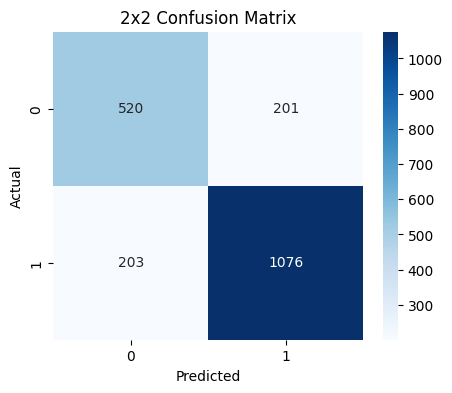

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_test_binary = (y_test == 1).astype(int)
y_pred_binary = (y_pred == 1).astype(int)
cm = confusion_matrix(y_test_binary, y_pred_binary)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2x2 Confusion Matrix")
plt.show()

In [35]:
#  MSE
from sklearn.metrics import mean_squared_error as mse
mse(y_test, y_pred)

1.623

In [36]:
# MSE & MAE
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Mean_squared_error:-",mean_squared_error(y_test, y_pred))
print("Mean_absolute_error:-",mean_absolute_error(y_test, y_pred))

Mean_squared_error:- 1.623
Mean_absolute_error:- 0.689


In [37]:
rmse=np.sqrt(mean_squared_error(y_test, y_pred))

In [38]:
rmse

np.float64(1.2739701723352868)

In [39]:
rmse=np.sqrt(mean_absolute_error(y_test, y_pred))

In [40]:
rmse

np.float64(0.8300602387778853)